# Datenaufbereitung: Philadelphia-Netzwerk → PyG-Split

Dieses Notebook ist die **einzige Stelle**, an der Daten geladen, exploriert und in einen
Train/Val/Test-Split überführt werden. Die Modell-Notebooks (`GATV2.ipynb`, `GINE.ipynb`)
laden ausschließlich die hier gespeicherte Datei `processed/philadelphia_split.pt` und
rechnen damit garantiert auf **identischen Daten**.

Die eigentliche Logik liegt im Paket `gnn_pipeline/`:

| Modul | Inhalt |
|---|---|
| `download.py` | Datensatz laden/entpacken |
| `parsing.py` | `.tntp`-Dateien → DataFrames |
| `features.py` | Kanten-Features, **Knoten-Feature-Registry**, `FeatureConfig` |
| `graph.py` | PyG `Data`, **paarweiser Split** (reziprok-sicher, siehe unten), Kantenfeatures an Splits |
| `io.py` | Split speichern/laden |
| `training.py` | gemeinsamer Trainingsloop für alle Modelle |

**Workflow bei Änderungen an den Daten:** `FeatureConfig` unten anpassen → Notebook komplett
ausführen → Modell-Notebooks neu starten.

In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from gnn_pipeline import (
    ensure_dataset, load_network,
    FeatureConfig, NODE_FEATURE_BUILDERS,
    build_graph, split_graph, GraphBundle, save_bundle,
)

network_dir = ensure_dataset()          # lädt nur, wenn der Ordner fehlt
frames = load_network(network_dir)      # frames.nodes, frames.edges
nodes_df, edges_df = frames.nodes, frames.edges

display(nodes_df.head())
display(edges_df.head())

Datensatz bereits vorhanden: TransportationNetworks_master\TransportationNetworks-master\Philadelphia
Philadelphia: 13389 Knoten (1489 Zonen), 40003 Kanten


,node_id,x,y,type
0,1,30208.0,74789.0,zone
1,2,30224.0,74793.0,zone
2,3,30247.0,74783.0,zone
3,4,30220.0,74767.0,zone
4,5,30243.0,74752.0,zone


,from_node,to_node,Capacity,Length,free_flow_time,B,Power,Speed_Limit,Toll,Type
0,1,4067,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
1,1,4073,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
2,1,4075,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
3,1,8400,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
4,2,4059,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7


# Explorative Analyse

Die Plots dienen nur dem Verständnis der Rohdaten und haben keinen Einfluss auf den Split.

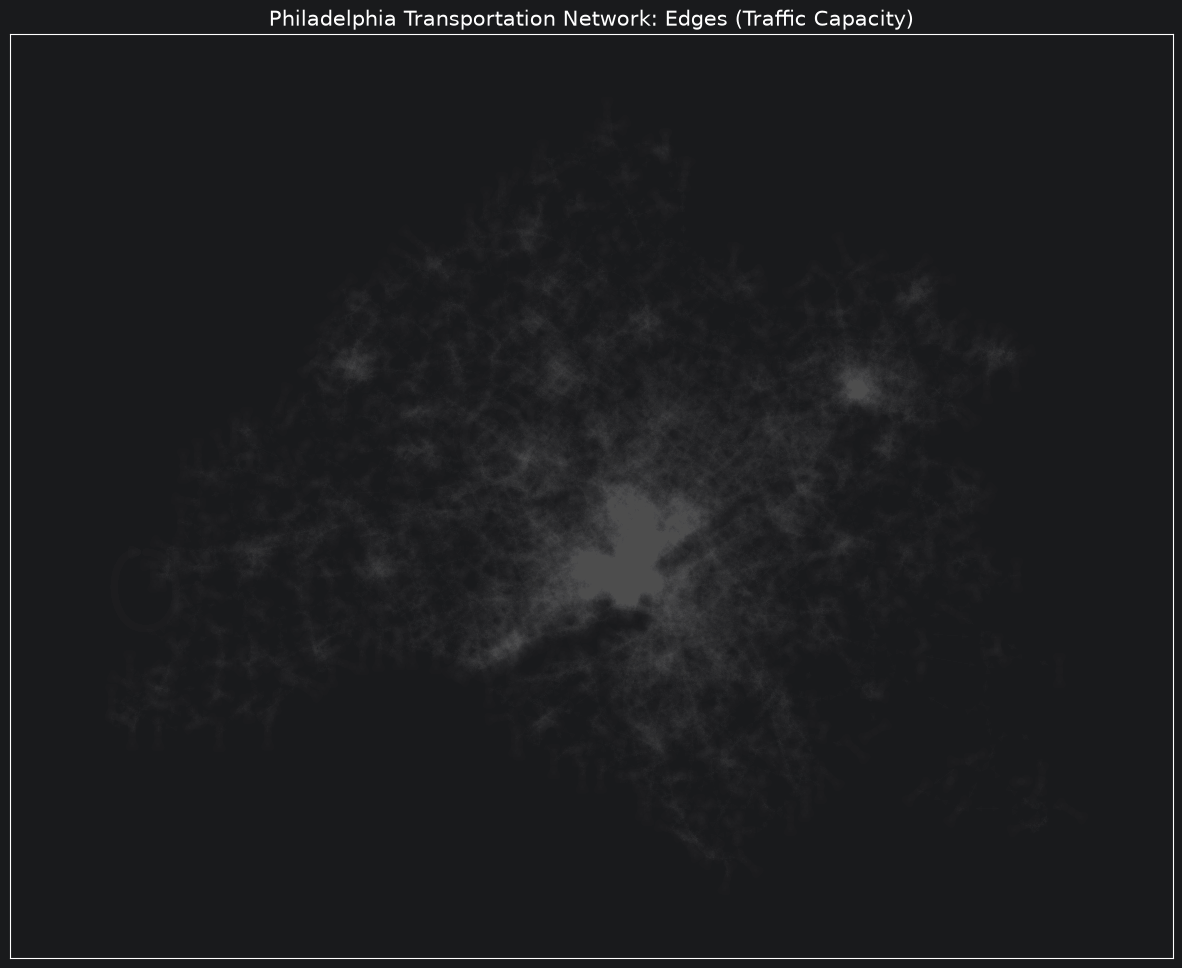

In [20]:
# Netzwerk-Plot: Kantenbreite ∝ Kapazität
G = nx.DiGraph()
pos = {int(r.node_id): (r.x, r.y) for r in nodes_df.itertuples()}
G.add_nodes_from(pos.keys())
G.add_edges_from(zip(edges_df['from_node'], edges_df['to_node']))
edge_widths = (edges_df['Capacity'] / edges_df['Capacity'].max() * 5 + 0.5).tolist()

plt.figure(figsize=(15, 12))
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', arrowsize=10, alpha=0.02)
plt.title('Philadelphia Transportation Network: Edges (Traffic Capacity)', size=15)
plt.xticks([]); plt.yticks([])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

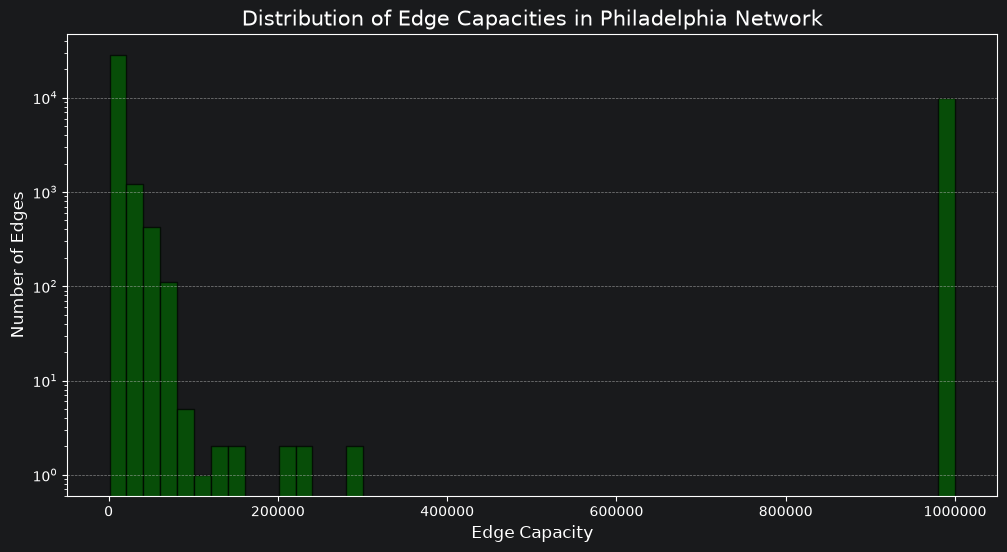

In [21]:
# Verteilung der Kantenkapazitäten (Platzhalter 999999 fällt als Ausreißer auf)
plt.figure(figsize=(12, 6))
plt.hist(edges_df['Capacity'], bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
plt.title('Distribution of Edge Capacities in Philadelphia Network', size=15)
plt.xlabel('Edge Capacity', size=12); plt.ylabel('Number of Edges', size=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

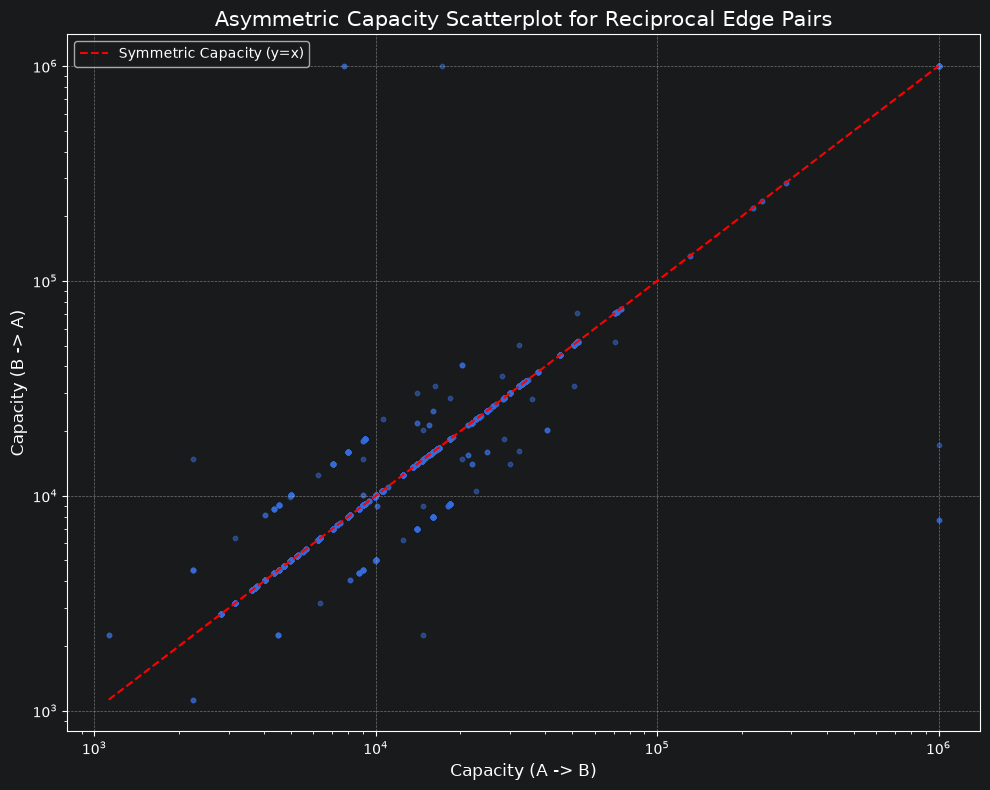

In [22]:
# Asymmetrische Kapazitäten reziproker Kantenpaare
df_forward = edges_df[['from_node', 'to_node', 'Capacity']].rename(columns={'Capacity': 'capacity_ab'})
df_backward = edges_df[['to_node', 'from_node', 'Capacity']].rename(
    columns={'to_node': 'from_node', 'from_node': 'to_node', 'Capacity': 'capacity_ba'})
reciprocal_edges = pd.merge(df_forward, df_backward, on=['from_node', 'to_node'], how='inner')

plt.figure(figsize=(10, 8))
plt.scatter(reciprocal_edges['capacity_ab'], reciprocal_edges['capacity_ba'], alpha=0.5, s=10)
plt.title('Asymmetric Capacity Scatterplot for Reciprocal Edge Pairs', size=15)
plt.xlabel('Capacity (A -> B)', size=12); plt.ylabel('Capacity (B -> A)', size=12)
plt.xscale('log'); plt.yscale('log')
lo = min(reciprocal_edges['capacity_ab'].min(), reciprocal_edges['capacity_ba'].min())
hi = max(reciprocal_edges['capacity_ab'].max(), reciprocal_edges['capacity_ba'].max())
plt.plot([lo, hi], [lo, hi], color='red', linestyle='--', label='Symmetric Capacity (y=x)')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend(); plt.tight_layout()
plt.show()

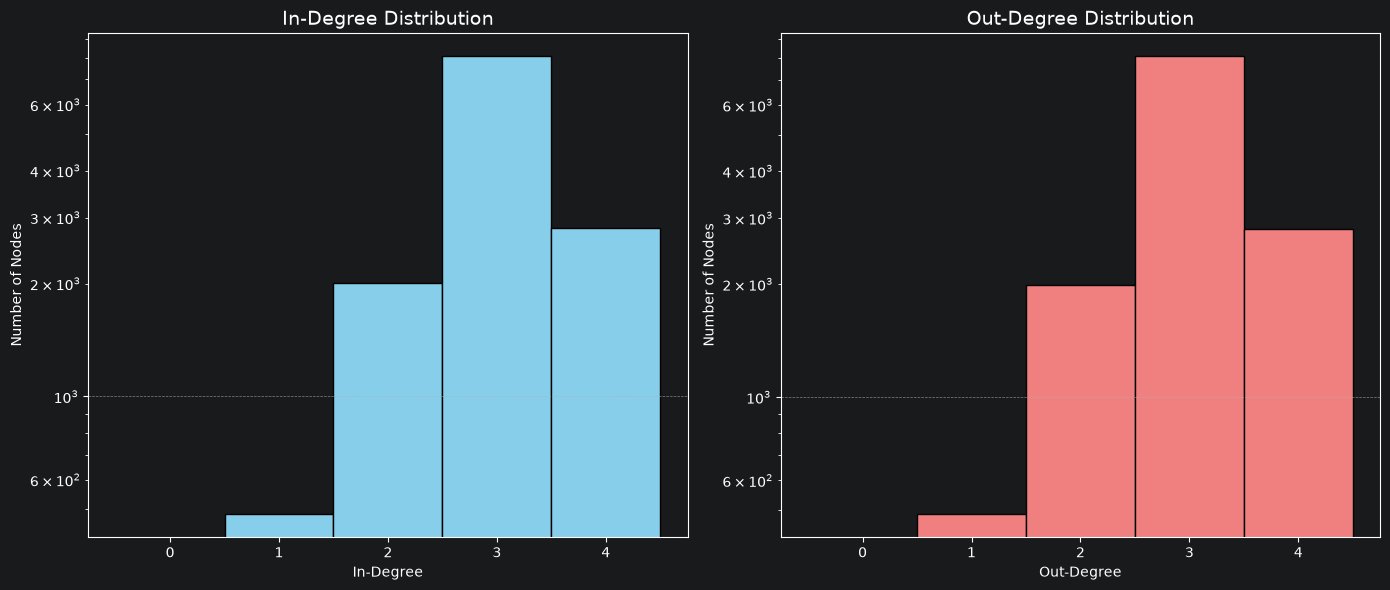

In [23]:
# In-/Out-Grad-Verteilungen
in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(in_degrees, bins=range(max(in_degrees) + 2), color='skyblue', edgecolor='black', align='left')
plt.title('In-Degree Distribution', size=14); plt.xlabel('In-Degree'); plt.ylabel('Number of Nodes')
plt.grid(axis='y', linestyle='--', alpha=0.7); plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(out_degrees, bins=range(max(out_degrees) + 2), color='lightcoral', edgecolor='black', align='left')
plt.title('Out-Degree Distribution', size=14); plt.xlabel('Out-Degree'); plt.ylabel('Number of Nodes')
plt.grid(axis='y', linestyle='--', alpha=0.7); plt.yscale('log')
plt.tight_layout()
plt.show()

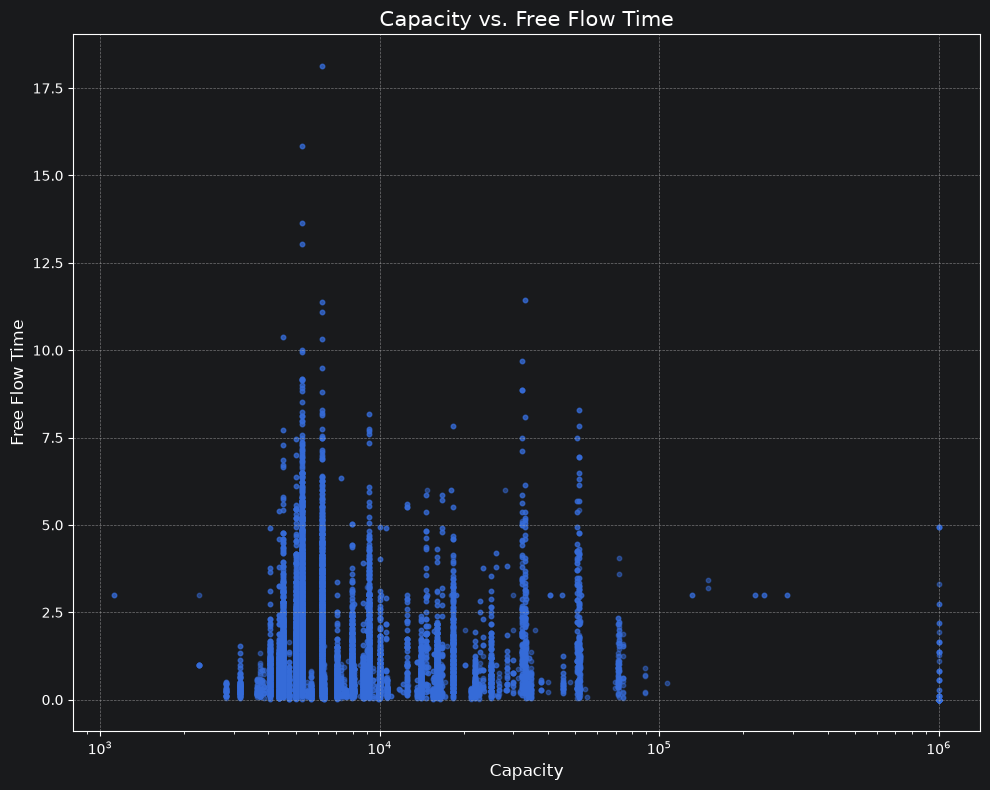

In [24]:
# Kapazität vs. Free Flow Time
plt.figure(figsize=(10, 8))
plt.scatter(edges_df['Capacity'], edges_df['free_flow_time'], alpha=0.5, s=10)
plt.title('Capacity vs. Free Flow Time', size=15)
plt.xlabel('Capacity', size=12); plt.ylabel('Free Flow Time', size=12)
if edges_df['Capacity'].min() > 0:
    plt.xscale('log')
if edges_df['free_flow_time'].min() > 0:
    plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
plt.show()

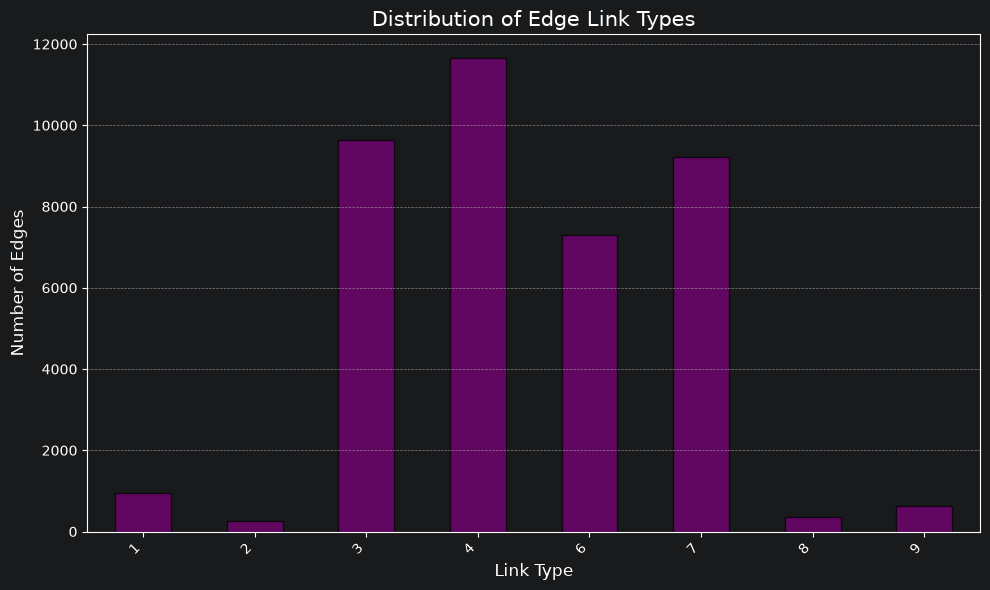

In [25]:
# Verteilung der Link-Typen
link_type_counts = edges_df['Type'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
link_type_counts.plot(kind='bar', color='purple', edgecolor='black', alpha=0.7)
plt.title('Distribution of Edge Link Types', size=15)
plt.xlabel('Link Type', size=12); plt.ylabel('Number of Edges', size=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7); plt.tight_layout()
plt.show()

# Feature-Konfiguration

Hier wird festgelegt, was in `data.x` (Knoten) und `data.edge_attr` (Kanten) landet.
**Das ist die zentrale Stellschraube für Experimente an der Datenmanipulation.**

Verfügbare Knotenfeatures (Registry in `gnn_pipeline/features.py`):

| Name | Spalten | Beschreibung |
|---|---|---|
| `coords` | `x`, `y` | Rohkoordinaten (Baseline aus dem ursprünglichen GATv2-Notebook) |
| `node_type` | `is_zone` | 1 = Zone (Origin/Destination), 0 = Kreuzung |
| `degree` | `log_in_degree`, `log_out_degree` | Grad auf dem vollen Graphen (siehe Leakage-Hinweis im Docstring) |
| `capacity_stats` | `log_capacity_in`, `log_capacity_out` | Summe realer Kapazität ein-/ausgehend |

Alle gewählten Features werden standardmäßig mit `StandardScaler` skaliert
(`scale_node_features=True`).

In [26]:
print("Registrierte Knotenfeatures:", sorted(NODE_FEATURE_BUILDERS))

config = FeatureConfig(
    # Baseline wie bisher: nur Koordinaten. Für Experimente z. B.:
    # node_features=["coords", "node_type", "degree"],
    node_features=["coords"],
    scale_node_features=True,

    edge_numerical=["Capacity", "Length", "free_flow_time", "Toll", "capacity_ratio", "delta_x", "delta_y"],
    edge_binary=["capacity_is_placeholder", "has_reciprocal"],
    one_hot_link_type=True,
    scale_edge_numerical=True,   # bisheriges Verhalten; True probieren, falls Training instabil ist
)

SEED = 42
VAL_RATIO, TEST_RATIO, NEG_RATIO = 0.1, 0.1, 2.0

Registrierte Knotenfeatures: ['capacity_stats', 'coords', 'degree', 'node_type', 'toll_share']


## Eigenes Knotenfeature ergänzen

Ein neues Feature braucht nur eine Funktion `(nodes_df, edges_df) -> DataFrame` mit einer
Zeile pro Knoten (Index wie `nodes_df`). Entweder dauerhaft in `gnn_pipeline/features.py`
oder zum Ausprobieren direkt hier im Notebook:

In [27]:
from gnn_pipeline import register_node_feature
import numpy as np

@register_node_feature("toll_share")
def _toll_share(nodes_df, edges_df):
    """Anteil mautpflichtiger ausgehender Kanten pro Knoten."""
    has_toll = edges_df.assign(toll=(edges_df["Toll"] > 0).astype(float))
    share = has_toll.groupby("from_node")["toll"].mean()
    return pd.DataFrame({"toll_share": nodes_df["node_id"].map(share).fillna(0).values}, index=nodes_df.index)

# Aktivieren durch: config.node_features.append("toll_share")
print("Registrierte Knotenfeatures:", sorted(NODE_FEATURE_BUILDERS))

Registrierte Knotenfeatures: ['capacity_stats', 'coords', 'degree', 'node_type', 'toll_share']


# Graph bauen, splitten, speichern

In [28]:
data, edges_feat_df, nodes_sorted, node_cols, edge_cols = build_graph(frames, config)

print(data)
print("Knotenfeatures:", node_cols)
print("Kantenfeatures:", edge_cols)
display(edges_feat_df.head())

Data(x=[13389, 2], edge_index=[2, 40003], edge_attr=[40003, 17], num_nodes=13389)
Knotenfeatures: ['x', 'y']
Kantenfeatures: ['Capacity', 'Length', 'free_flow_time', 'Toll', 'capacity_ratio', 'delta_x', 'delta_y', 'capacity_is_placeholder', 'has_reciprocal', 'link_type_1', 'link_type_2', 'link_type_3', 'link_type_4', 'link_type_6', 'link_type_7', 'link_type_8', 'link_type_9']


,from_node,to_node,Capacity,Length,free_flow_time,Toll,capacity_is_placeholder,link_type_1,link_type_2,link_type_3,...,link_type_6,link_type_7,link_type_8,link_type_9,has_reciprocal,capacity_ratio,delta_x,delta_y,from_node_mapped,to_node_mapped
0,1,4067,999999.0,0.12,0.0,0.0,1,False,False,False,...,False,True,False,False,1,1.0,3.0,2.0,0,4066
1,1,4073,999999.0,0.12,0.0,0.0,1,False,False,False,...,False,True,False,False,1,1.0,1.0,10.0,0,4072
2,1,4075,999999.0,0.12,0.0,0.0,1,False,False,False,...,False,True,False,False,1,1.0,3.0,4.0,0,4074
3,1,8400,999999.0,0.12,0.0,0.0,1,False,False,False,...,False,True,False,False,1,1.0,4.0,3.0,0,8399
4,2,4059,999999.0,0.12,0.0,0.0,1,False,False,False,...,False,True,False,False,1,1.0,1.0,3.0,1,4058


## Split: paarweise statt kantenweise (Fix für den reziproken Leak)

**Problem.** Der bisherige Split (`RandomLinkSplit(is_undirected=False)`) hat jede *gerichtete* Kante
unabhängig in Train/Val/Test gezogen. Das Philadelphia-Netz ist aber fast vollständig reziprok
(~94 % der Kanten haben eine Gegenkante, siehe `has_reciprocal`). Folge: Für **76.8 % der Val- und
75.8 % der Test-Kanten** A→B lag die Gegenrichtung B→A im Train-Message-Passing-Graphen. Das Modell hat
B→A also beim Message Passing gesehen und sollte A→B „vorhersagen" – eine Aufgabe, die auch ein reines
GIN *ohne jedes Kantenfeature* mit AUC 0.997 löst (Ablation in `GINE.ipynb`). Die hohen AUCs beider
Modelle waren damit zu großen Teilen ein Artefakt des Splits, nicht Modellqualität.

**Lösung** (`gnn_pipeline/graph.py`, `split_graph(pair_aware=True)`, jetzt Standard):

1. Alle gerichteten Kanten werden auf ungeordnete Knotenpaare {u, v} abgebildet.
2. Die **Paare** werden mit festem Seed in Train/Val/Test aufgeteilt; beide Richtungen eines Paars
   erben denselben Split. Damit kann keine Gegenrichtung mehr in den Trainingsgraphen rutschen.
3. Positive Label = die tatsächlich existierenden gerichteten Kanten des Splits
   (Einbahnstraßen also nur in ihrer einen Richtung).
4. Negative Label = zufällige Paare, die in **keiner** Richtung existieren, jeweils in beide Richtungen
   eingetragen. So bleibt neg/pos ≈ `NEG_RATIO`, und die Negativen werden symmetrisch behandelt.
5. Message-Passing-Graphen wie bei `RandomLinkSplit`: Train und Val nutzen die Train-Kanten,
   Test zusätzlich die Val-Kanten.

**Was sich für die Modell-Notebooks ändert:** nichts an der Schnittstelle – `edge_index`, `edge_attr`,
`edge_label_index`, `edge_label`, `edge_label_attr` wie bisher. Die AUC-Werte werden sinken; das ist
der ehrliche Wert. `bundle.summary()` weist den Leak jetzt explizit aus, `meta["split"]` dokumentiert
die Variante. Der alte Split bleibt über `pair_aware=False` reproduzierbar (Kontrollzelle unten).

In [29]:
PAIR_AWARE = True   # False = alter kantenweiser RandomLinkSplit (reziproker Leak, nur zum Vergleich)

train_data, val_data, test_data = split_graph(
    data, seed=SEED, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO,
    neg_sampling_ratio=NEG_RATIO, pair_aware=PAIR_AWARE,
)

bundle = GraphBundle(
    data=data, train=train_data, val=val_data, test=test_data,
    node_feature_columns=node_cols, edge_attr_columns=edge_cols,
    node_type=nodes_sorted["type"].tolist(),
    original_node_ids=nodes_sorted["node_id"].tolist(),
    meta={"seed": SEED, "val_ratio": VAL_RATIO, "test_ratio": TEST_RATIO,
          "neg_sampling_ratio": NEG_RATIO, "node_features": list(config.node_features),
          "split": "pair_aware" if PAIR_AWARE else "directed_random_link_split",
          "scale_edge_numerical": config.scale_edge_numerical},
)
print(bundle.summary())
save_bundle(bundle)   # -> processed/philadelphia_split.pt

Knoten: 13389, Kanten: 40003
Knotenfeatures (2): ['x', 'y']
Kantenfeatures (17): ['Capacity', 'Length', 'free_flow_time', 'Toll', 'capacity_ratio', 'delta_x', 'delta_y', 'capacity_is_placeholder', 'has_reciprocal', 'link_type_1', 'link_type_2', 'link_type_3', 'link_type_4', 'link_type_6', 'link_type_7', 'link_type_8', 'link_type_9']
train: msg-passing Kanten=31995, Label-Paare pos=31995 neg=63990
val: msg-passing Kanten=31995, Label-Paare pos=3999 neg=7998
test: msg-passing Kanten=35994, Label-Paare pos=4009 neg=8018
val: positive Kanten mit Gegenrichtung im Train-Graph: 0/3999 (0.0%)
test: positive Kanten mit Gegenrichtung im Train-Graph: 0/4009 (0.0%)
meta: {'seed': 42, 'val_ratio': 0.1, 'test_ratio': 0.1, 'neg_sampling_ratio': 2.0, 'node_features': ['coords'], 'split': 'pair_aware', 'scale_edge_numerical': True}
Split gespeichert: processed\philadelphia_split.pt


'processed\\philadelphia_split.pt'

In [30]:
# Kontrolle: reziproker Leak im neuen Split vs. im alten kantenweisen Split
from gnn_pipeline import reverse_edge_leakage

for name, split in [("val", val_data), ("test", test_data)]:
    leaked, total = reverse_edge_leakage(train_data, split)
    assert leaked == 0, f"{name}: {leaked} positive Kanten haben ihre Gegenrichtung im Train-Graph"
print("Neuer Split: keine Val-/Test-Kante hat ihre Gegenrichtung im Train-Message-Passing-Graph.")

old_train, old_val, old_test = split_graph(
    data, seed=SEED, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, neg_sampling_ratio=NEG_RATIO, pair_aware=False
)
for name, split in [("val", old_val), ("test", old_test)]:
    leaked, total = reverse_edge_leakage(old_train, split)
    print(f"Alter Split ({name}): {leaked}/{total} = {leaked / total:.1%} der positiven Kanten geleakt")

Neuer Split: keine Val-/Test-Kante hat ihre Gegenrichtung im Train-Message-Passing-Graph.
Alter Split (val): 3074/4000 = 76.8% der positiven Kanten geleakt
Alter Split (test): 3034/4000 = 75.8% der positiven Kanten geleakt
